# Problem 243: Resilience

https://projecteuler.net/problem=243

A positive fraction whose numerator is less than its denominator is called a proper fraction.
For any denominator, $d$, there will be $d - 1$ proper fractions; for example, with $d = 12$:
$1/12, 2/12, 3/12, 4/12, 5/12, 6/12, 7/12, 8/12, 9/12, 10/12, 11/12$.

We shall call a fraction that cannot be cancelled down a **resilient fraction**.
Furthermore we shall define the **resilience** of a denominator, $R(d)$, to be the ratio of its proper fractions that are resilient; for example, $R(12) = 4/11$.
In fact, $d = 12$ is the smallest denominator having a resilience $R(d) < 4/10$.

Find the smallest denominator $d$, having a resilience $R(d) < 15499/94744$.

## Brute force

The number of resilient fractions for denominator $d$ is $\varphi(d)$ (Euler's totient), since a fraction $k/d$ is irreducible iff $\gcd(k, d) = 1$. So:

$$R(d) = \frac{\varphi(d)}{d - 1}$$

Brute force computes $\varphi(d)$ by counting $k \in \{1, \ldots, d-1\}$ with $\gcd(k, d) = 1$.

In [2]:
from math import gcd

def resilience(d: int) -> float:
    phi = sum(1 for k in range(1, d) if gcd(k, d) == 1)
    return phi / (d - 1)

# Verify example: R(12) = 4/11
assert resilience(12) == 4 / 11, f"Expected 4/11, got {resilience(12)}"
print(f"R(12) = {resilience(12):.6f}  (4/11 = {4/11:.6f})  ✓")

R(12) = 0.363636  (4/11 = 0.363636)  ✓


## Resilience plot

Plot $R(d)$ for $d = 2, \ldots, 500$ alongside the target threshold $15499/94744$. Primes cause spikes (all $k < p$ are coprime to $p$, so $R(p) = (p-1)/(p-1) = 1$), while highly composite numbers pull $R(d)$ down.

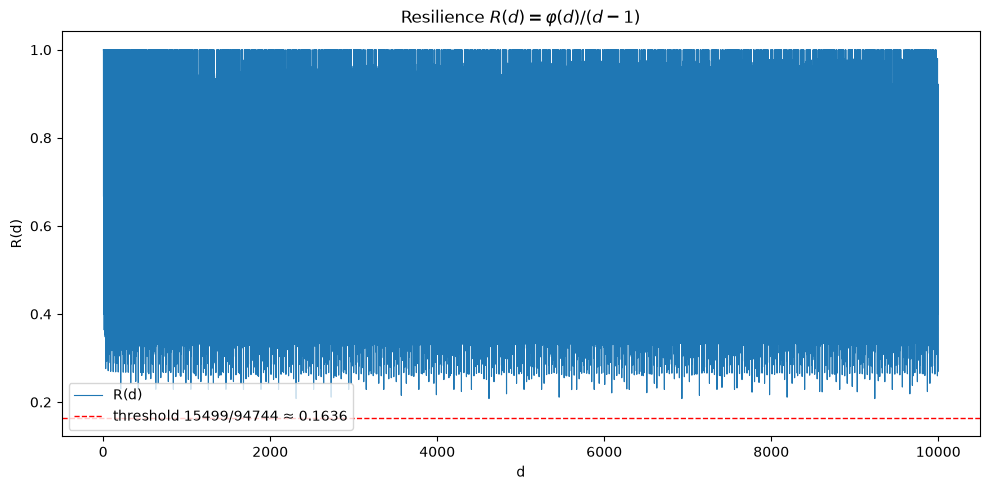

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

N = 10000
ds = list(range(2, N + 1))
rs = [resilience(d) for d in ds]
threshold = 15499 / 94744

plt.figure(figsize=(10, 5))
plt.plot(ds, rs, lw=0.8, label="R(d)")
plt.axhline(threshold, color="red", lw=1, linestyle="--", label=f"threshold 15499/94744 ≈ {threshold:.4f}")
plt.xlabel("d")
plt.ylabel("R(d)")
plt.title("Resilience $R(d) = \\varphi(d) / (d-1)$")
plt.legend()
plt.tight_layout()
plt.show()

## Analytical solution

The brute-force scan is far too slow: the answer turns out to be ~900 million, making a linear scan infeasible.

**Key identity:**

$$R(d) = \frac{\varphi(d)}{d-1} = \frac{d}{d-1} \prod_{p \mid d} \frac{p-1}{p}$$

The product depends only on the *distinct* prime factors of $d$. To minimise $R(d)$, we want that product as small as possible — which means using the **smallest possible primes**, i.e. consecutive primes starting from 2.

**Step 1 — How many primes do we need?**

Define $Q_k = \prod_{i=1}^k \frac{p_i - 1}{p_i}$. Since $\frac{d}{d-1} \to 1$ as $d \to \infty$, the target $T = 15499/94744$ is reachable only if $Q_k < T$. Find the smallest $k$ where this holds.

**Step 2 — Lower bound on $d$:**

Once we have $k$, we need $\frac{d}{d-1} \cdot Q_k < T$, which gives $d > \frac{T}{T - Q_k}$.

**Step 3 — Smallest valid $d$:**

$d$ must be divisible by the primorial $P_k = p_1 \cdots p_k$. We pick the smallest multiple of $P_k$ that exceeds the lower bound. Numbers with more than $k$ distinct primes start at $P_{k+1} > P_k \cdot p_{k+1}$, which is larger than our answer, so they cannot win.

In [6]:
from fractions import Fraction
import math

def gen_primes():
    """Yield primes via trial division — sufficient for the small count needed here."""
    yield 2
    n = 3
    while True:
        if all(n % p for p in range(3, int(n**0.5) + 1, 2)):
            yield n
        n += 2

T = Fraction(15499, 94744)

# Step 1: find how many leading primes are needed so that Q_k < T
primes = []
Q = Fraction(1)
for p in gen_primes():
    Q *= Fraction(p - 1, p)
    primes.append(p)
    if Q < T:
        break

k = len(primes)
print(f"Need first {k} primes (up to {primes[-1]})")
print(f"Q_{k} = {Q} ≈ {float(Q):.10f}")
print(f"T     = {T} ≈ {float(T):.10f}")

# Step 2: primorial P_k and lower bound on d
P = math.prod(primes)
print(f"\nP_{k} = {P}")

lower = T / (T - Q)
print(f"Lower bound: d > {lower} ≈ {float(lower):.2f}")

# Step 3: smallest multiple of P_k above the lower bound (exact arithmetic)
m = math.ceil(float(lower) / P)
while Fraction(P * m, P * m - 1) * Q >= T:
    m += 1

answer = P * m
print(f"\nAnswer: {m} × P_{k} = {answer}")

Need first 9 primes (up to 23)
Q_9 = 110592/676039 ≈ 0.1635881954
T     = 15499/94744 ≈ 0.1635881956

P_9 = 223092870
Lower bound: d > 805994497 ≈ 805994497.00

Answer: 4 × P_9 = 892371480
